In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard

2026-04-15 15:10:23.923948: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776265824.340400      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776265824.466522      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776265825.510563      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776265825.510614      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776265825.510617      24 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1776265862.635657      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776265862.638572      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/50


I0000 00:00:1776265866.155206      72 service.cc:152] XLA service 0x7de4e900a090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776265866.155249      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776265866.155252      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776265866.523757      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


 71/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5118

I0000 00:00:1776265867.552052      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3880 - val_loss: 0.2653
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2651 - val_loss: 0.2616
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2601 - val_loss: 0.2503
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2465 - val_loss: 0.2315
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2275 - val_loss: 0.2128
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2097 - val_loss: 0.1977
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1956 - val_loss: 0.1862
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1846 - val_loss: 0.1768
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1758 - val_loss: 0.1690
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1682 - val_loss: 0.1618
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1610 - val_loss: 0.1549
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.

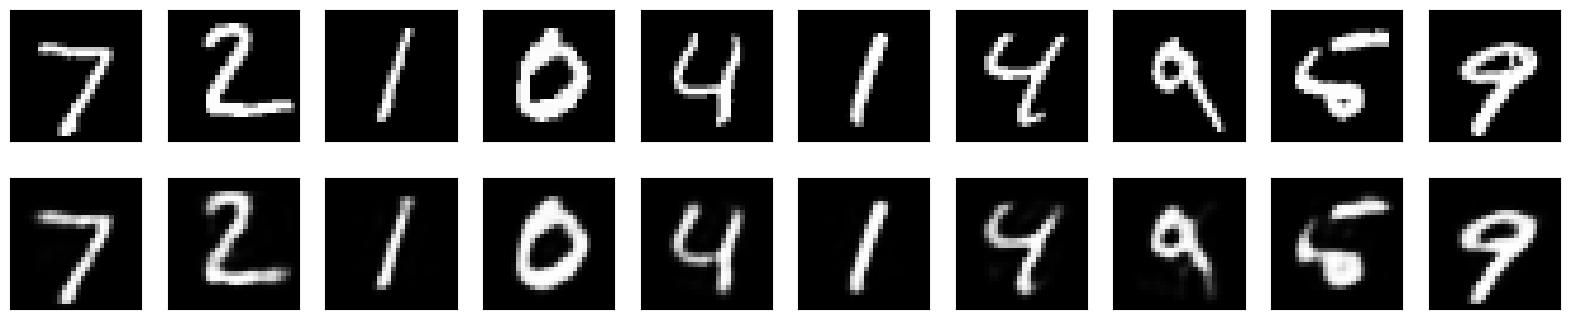

In [3]:
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 64  # 32 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.4803 - val_loss: 0.2277
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2218 - val_loss: 0.2075
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2088 - val_loss: 0.2169
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2018 - val_loss: 0.1868
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1880 - val_loss: 0.1784
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1882 - val_loss: 0.1785
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1776 - val_loss: 0.1662
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1770 - val_loss: 0.1684
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1704 - val_loss: 0.1603
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1638 - val_loss: 0.1606
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1654 - val_loss: 0.2334
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

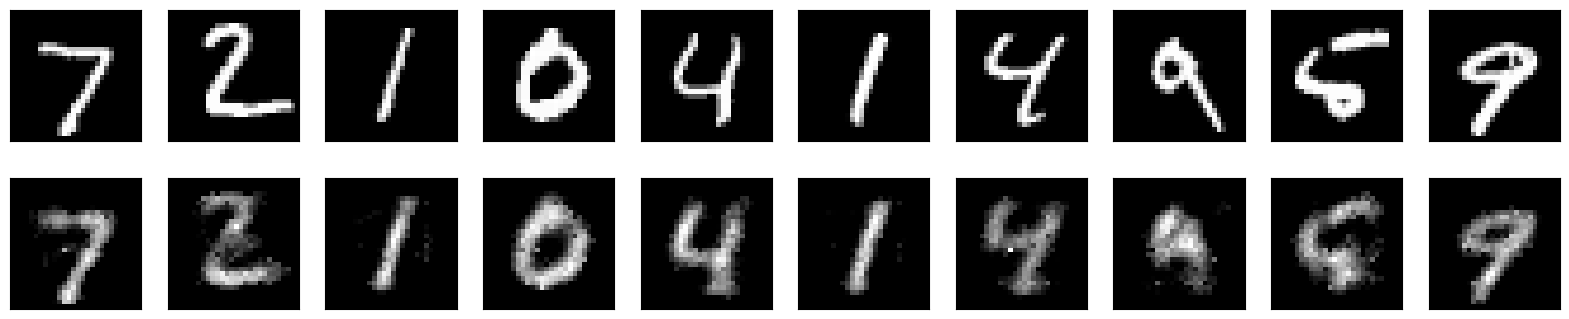

In [4]:
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 32  # 32 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='relu')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

1. encoded_dimensions    Activation       Loss
2.  64                     softmax       0.084
3.  32                     softmax       0.185
4.  32                      relu         0.206


**Train Autoencoder (784 → 32)
Extract latent vectors
Train FNN on latent space
Compare with:
Raw pixels + FNN
CNN**

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 → 784
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 34.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.15MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.74MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.04MB/s]


In [7]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)   # latent space
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [8]:
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 5

for epoch in range(epochs):
    total_loss = 0
    
    for data, _ in train_loader:
        data = data.to(device)
        
        output = model(data)
        loss = criterion(output, data)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.05917764294630429
Epoch 2, Loss: 0.0295383010838014
Epoch 3, Loss: 0.02378847251441687
Epoch 4, Loss: 0.020774484713321557
Epoch 5, Loss: 0.018434535269178688


In [9]:
def extract_latent(model, loader):
    model.eval()
    latents = []
    labels = []
    
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            z = model.encoder(data)
            
            latents.append(z.cpu())
            labels.append(target)
    
    return torch.cat(latents), torch.cat(labels)

train_latent, train_labels = extract_latent(model, train_loader)
test_latent, test_labels = extract_latent(model, test_loader)

print(train_latent.shape)  # should be [60000, 32]

torch.Size([60000, 32])


In [10]:
class LatentClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    
    def forward(self, x):
        return self.net(x)

In [11]:
clf = LatentClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(clf.parameters(), lr=1e-3)

for epoch in range(5):
    clf.train()
    total_loss = 0
    
    for i in range(0, len(train_latent), 128):
        x = train_latent[i:i+128].to(device)
        y = train_labels[i:i+128].to(device)
        
        output = clf(x)
        loss = criterion(output, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 268.51986253261566
Epoch 2, Loss: 132.80982861667871
Epoch 3, Loss: 110.47554432600737
Epoch 4, Loss: 97.37644942849874
Epoch 5, Loss: 88.46860954165459


In [12]:
clf.eval()
correct = 0

with torch.no_grad():
    for i in range(0, len(test_latent), 128):
        x = test_latent[i:i+128].to(device)
        y = test_labels[i:i+128].to(device)
        
        preds = clf(x).argmax(dim=1)
        correct += (preds == y).sum().item()

accuracy = correct / len(test_latent)
print("Latent FNN Accuracy:", accuracy)

Latent FNN Accuracy: 0.9453


In [13]:
class RawFNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.net(x)

In [14]:
raw_model = RawFNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(raw_model.parameters(), lr=1e-3)

for epoch in range(5):
    raw_model.train()
    total_loss = 0
    
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        
        output = raw_model(data)
        loss = criterion(output, target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.4114238108589705
Epoch 2, Loss: 0.1946690378984663
Epoch 3, Loss: 0.14084850538021593
Epoch 4, Loss: 0.10951332531885298
Epoch 5, Loss: 0.08669252094350008


In [15]:
raw_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        
        outputs = raw_model(data)
        _, preds = torch.max(outputs, 1)
        
        correct += (preds == target).sum().item()
        total += target.size(0)

print(f"Raw FNN Accuracy: {100 * correct / total:.2f}%")

Raw FNN Accuracy: 97.30%


In [16]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),  # (28x28 → 28x28)
            nn.ReLU(),
            nn.MaxPool2d(2),                # (28x28 → 14x14)
            
            nn.Conv2d(16, 32, 3, padding=1), # (14x14 → 14x14)
            nn.ReLU(),
            nn.MaxPool2d(2)                 # (14x14 → 7x7)
        )
        
        self.fc = nn.Linear(32 * 7 * 7, 10)
    
    def forward(self, x):
        x = x.view(-1, 1, 28, 28)  # reshape flat → image
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [17]:
cnn_model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3)

for epoch in range(5):
    cnn_model.train()
    total_loss = 0
    
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        
        output = cnn_model(data)
        loss = criterion(output, target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.3430473403191007
Epoch 2, Loss: 0.08947097061714257
Epoch 3, Loss: 0.06429088640727722
Epoch 4, Loss: 0.052326902410567505
Epoch 5, Loss: 0.04635072391388862


In [18]:
cnn_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        
        outputs = cnn_model(data)
        _, preds = torch.max(outputs, 1)
        
        correct += (preds == target).sum().item()
        total += target.size(0)

print(f"CNN Accuracy: {100 * correct / total:.2f}%")

CNN Accuracy: 98.61%
